In [1]:
import pandas as pd
import numpy as np
All_Data = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/5. Final consolidation of all data/5.A. Data created in 5./5.2./Final affiliations.xlsx') 
print(All_Data.shape)

(22790, 40)


In [2]:
mask_journal = All_Data['Journal_Name'].isin(['AER'])
AER_data = All_Data[mask_journal]
print(AER_data.shape)

(9340, 40)


In [3]:
AER_data.rename(columns = {'Year':'year'}, inplace = True)

melted = AER_data.melt(id_vars= ['Article_ID','year'], value_vars=['0_Auth_affs_0', '0_Auth_affs_1', '0_Auth_affs_2', '0_Auth_affs_3', '0_Auth_affs_4', 
                                '1_Auth_affs_0' , '1_Auth_affs_1', '1_Auth_affs_2', '1_Auth_affs_3', '1_Auth_affs_4',
                                '2_Auth_affs_0', '2_Auth_affs_1', '2_Auth_affs_2', '2_Auth_affs_3', '2_Auth_affs_4',
                                '3_Auth_affs_0', '3_Auth_affs_1', '3_Auth_affs_2', '3_Auth_affs_3', '3_Auth_affs_4',
                                '4_Auth_affs_0', '4_Auth_affs_1', '4_Auth_affs_2' , '4_Auth_affs_3',
                                '5_Auth_affs_0',
                                '6_Auth_affs_0','7_Auth_affs_0']).dropna()

melted.rename(columns = {'variable':'Aff number'}, inplace = True)
melted.rename(columns = {'value':'Affiliation'}, inplace = True)

melted = melted.sort_values(by=['year'])

print(melted.head())
print(melted.shape)

      Article_ID  year     Aff number                              Affiliation
9236     1805069  1940  0_Auth_affs_0  Pittsford New York United States (City)
9256     1807585  1940  0_Auth_affs_0                Michigan State University
9257     1807586  1940  0_Auth_affs_0                    Ohio State University
9258     1807587  1940  0_Auth_affs_0                         Brown University
9259     1807588  1940  0_Auth_affs_0                 University Of California
(15292, 4)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_45866/781024661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AER_data.rename(columns = {'Year':'year'}, inplace = True)


In [4]:
melted['aff_cum_counts'] = melted.groupby(['Affiliation']).cumcount()+1

melted = melted[['Article_ID' ,'Aff number', 'Affiliation','year', 'aff_cum_counts']]
melted.head()

,Article_ID,Aff number,Affiliation,year,aff_cum_counts
9236,1805069,0_Auth_affs_0,Pittsford New York United States (City),1940,1
9256,1807585,0_Auth_affs_0,Michigan State University,1940,1
9257,1807586,0_Auth_affs_0,Ohio State University,1940,1
9258,1807587,0_Auth_affs_0,Brown University,1940,1
9259,1807588,0_Auth_affs_0,University Of California,1940,1


In [5]:
# Mask to remove the National Bureau Of Economic Research
mask_journal = melted['Affiliation'].isin(['National Bureau Of Economic Research'])
melted = melted[~mask_journal]

# Checking the top 20 occurances of Universities over the 70 years
highest_vals = melted.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(20,'aff_cum_counts')
highest_vals_10

,Article_ID,Aff number,Affiliation,year,aff_cum_counts
46817,27805000,1_Auth_affs_0,Harvard University,2010,846
46813,27804996,1_Auth_affs_0,University Of Chicago,2010,543
46826,27805009,1_Auth_affs_0,Massachusetts Institute Of Technology,2010,509
46754,27871231,1_Auth_affs_0,Stanford University,2010,501
46803,27804986,1_Auth_affs_0,"University Of California, Berkeley",2010,448
46773,27804955,1_Auth_affs_0,Princeton University,2010,422
46794,27804977,1_Auth_affs_0,Yale University,2010,365
46809,27804992,1_Auth_affs_0,University Of Pennsylvania,2010,357
46818,27805001,1_Auth_affs_0,Columbia University,2010,345
46814,27804997,1_Auth_affs_0,University Of Michigan,2010,302


(71, 5)
        Article_ID     Aff number         Affiliation  year  aff_cum_counts
9310       1814505  0_Auth_affs_0  Harvard University  1940               6
149329     1816446  3_Auth_affs_0  Harvard University  1941              15
158547     1815118  3_Auth_affs_1  Harvard University  1942              25
8987       1811965  0_Auth_affs_0  Harvard University  1943              27
8948       1818710  0_Auth_affs_0  Harvard University  1944              28
       Article_ID     Aff number         Affiliation  year  aff_cum_counts
47608    30034667  1_Auth_affs_0  Harvard University  2006             733
47455    30034505  1_Auth_affs_0  Harvard University  2007             749
47287    29729975  1_Auth_affs_0  Harvard University  2008             784
93628    25592548  2_Auth_affs_0  Harvard University  2009             810
46817    27805000  1_Auth_affs_0  Harvard University  2010             846
(71, 5)


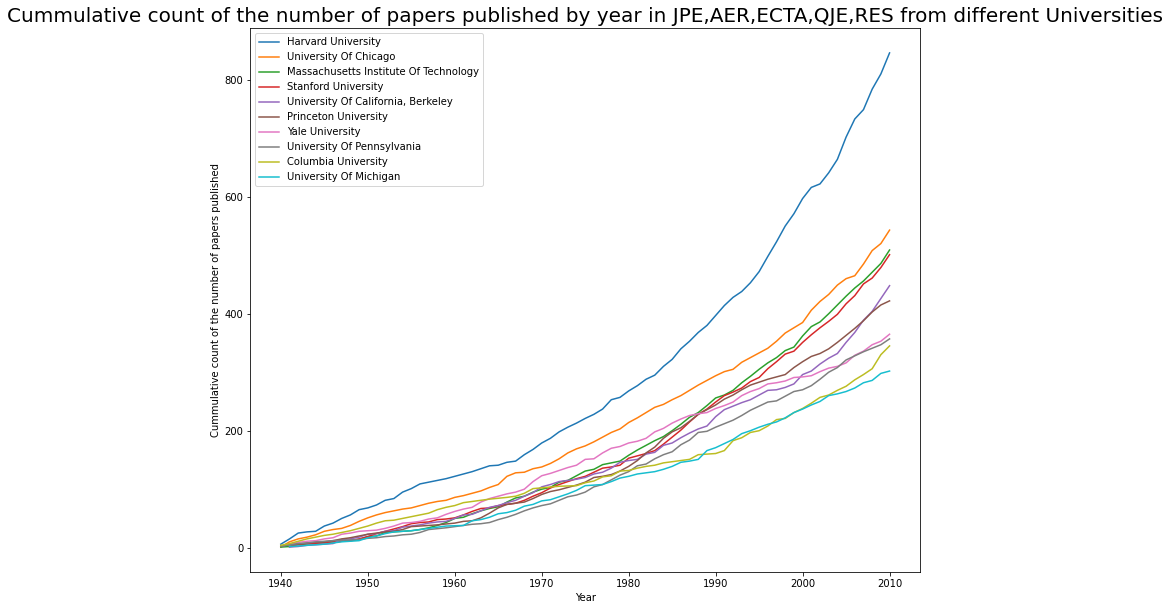

In [6]:
#Stacked plot on all years
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#print(melted.head())

a = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[0,2])].drop_duplicates(subset = ['year'], keep = 'last')
print(a.shape)
print(a.head())
print(a.tail())
b = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[1,2])].drop_duplicates(subset = ['year'], keep = 'last')
print(b.shape)
c = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[2,2])].drop_duplicates(subset = ['year'], keep = 'last')
d = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[3,2])].drop_duplicates(subset = ['year'], keep = 'last')
e = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[4,2])].drop_duplicates(subset = ['year'], keep = 'last')
f = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[5,2])].drop_duplicates(subset = ['year'], keep = 'last')
g = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[6,2])].drop_duplicates(subset = ['year'], keep = 'last')
h = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[7,2])].drop_duplicates(subset = ['year'], keep = 'last')
i = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[8,2])].drop_duplicates(subset = ['year'], keep = 'last')
j = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[9,2])].drop_duplicates(subset = ['year'], keep = 'last')
k = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[10,2])].drop_duplicates(subset = ['year'], keep = 'last')

plt.figure(figsize=(12,10))
plt.plot(a['year'],a['aff_cum_counts'], label = highest_vals_10.iat[0,2])
plt.plot(b['year'],b['aff_cum_counts'], label = highest_vals_10.iat[1,2])
plt.plot(c['year'],c['aff_cum_counts'], label = highest_vals_10.iat[2,2])
plt.plot(d['year'],d['aff_cum_counts'], label = highest_vals_10.iat[3,2])
plt.plot(e['year'],e['aff_cum_counts'], label = highest_vals_10.iat[4,2])
plt.plot(f['year'],f['aff_cum_counts'], label = highest_vals_10.iat[5,2])
plt.plot(g['year'],g['aff_cum_counts'], label = highest_vals_10.iat[6,2])
plt.plot(h['year'],h['aff_cum_counts'], label = highest_vals_10.iat[7,2])
plt.plot(i['year'],i['aff_cum_counts'], label = highest_vals_10.iat[8,2])
plt.plot(j['year'],j['aff_cum_counts'], label = highest_vals_10.iat[9,2])
#plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])

plt.title('Cummulative count of the number of papers published by year in JPE,AER,ECTA,QJE,RES from different Universities', fontsize=20)
plt.xlabel('Year')
plt.ylabel('Cummulative count of the number of papers published')

plt.legend()
plt.show()

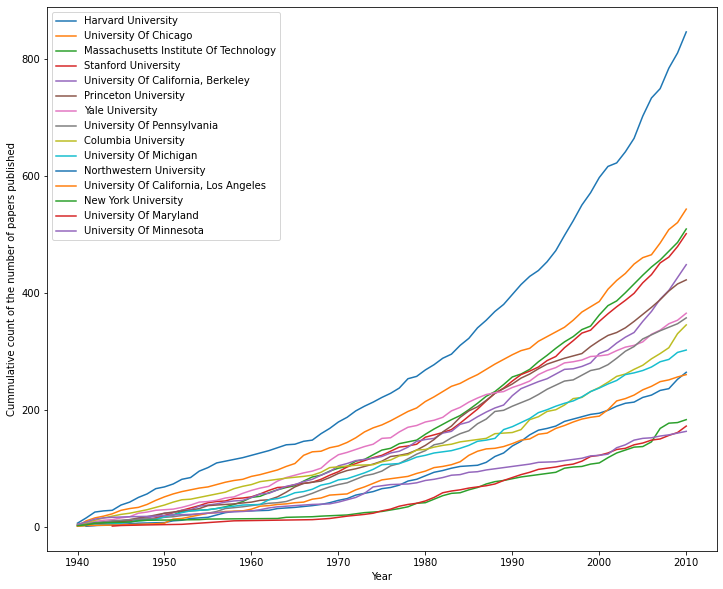

In [7]:
#Stacked plot on all years
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#print(melted.head())

a = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[0,2])].drop_duplicates(subset = ['year'], keep = 'last')
b = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[1,2])].drop_duplicates(subset = ['year'], keep = 'last')
c = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[2,2])].drop_duplicates(subset = ['year'], keep = 'last')
d = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[3,2])].drop_duplicates(subset = ['year'], keep = 'last')
e = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[4,2])].drop_duplicates(subset = ['year'], keep = 'last')
f = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[5,2])].drop_duplicates(subset = ['year'], keep = 'last')
g = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[6,2])].drop_duplicates(subset = ['year'], keep = 'last')
h = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[7,2])].drop_duplicates(subset = ['year'], keep = 'last')
i = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[8,2])].drop_duplicates(subset = ['year'], keep = 'last')
j = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[9,2])].drop_duplicates(subset = ['year'], keep = 'last')
k = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[10,2])].drop_duplicates(subset = ['year'], keep = 'last')
l = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[11,2])].drop_duplicates(subset = ['year'], keep = 'last')
m = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[12,2])].drop_duplicates(subset = ['year'], keep = 'last')
n = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[13,2])].drop_duplicates(subset = ['year'], keep = 'last')
o = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[14,2])].drop_duplicates(subset = ['year'], keep = 'last')
p = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[15,2])].drop_duplicates(subset = ['year'], keep = 'last')

plt.figure(figsize=(12,10))
plt.plot(a['year'],a['aff_cum_counts'], label = highest_vals_10.iat[0,2])
plt.plot(b['year'],b['aff_cum_counts'], label = highest_vals_10.iat[1,2])
plt.plot(c['year'],c['aff_cum_counts'], label = highest_vals_10.iat[2,2])
plt.plot(d['year'],d['aff_cum_counts'], label = highest_vals_10.iat[3,2])
plt.plot(e['year'],e['aff_cum_counts'], label = highest_vals_10.iat[4,2])
plt.plot(f['year'],f['aff_cum_counts'], label = highest_vals_10.iat[5,2])
plt.plot(g['year'],g['aff_cum_counts'], label = highest_vals_10.iat[6,2])
plt.plot(h['year'],h['aff_cum_counts'], label = highest_vals_10.iat[7,2])
plt.plot(i['year'],i['aff_cum_counts'], label = highest_vals_10.iat[8,2])
plt.plot(j['year'],j['aff_cum_counts'], label = highest_vals_10.iat[9,2])
plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])
plt.plot(l['year'],l['aff_cum_counts'], label = highest_vals_10.iat[11,2])
plt.plot(m['year'],m['aff_cum_counts'], label = highest_vals_10.iat[12,2])
plt.plot(n['year'],n['aff_cum_counts'], label = highest_vals_10.iat[13,2])
plt.plot(o['year'],o['aff_cum_counts'], label = highest_vals_10.iat[14,2])
#plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])

#plt.title('Cummulative count of the number of papers published by year in JPE,AER,ECTA,QJE,RES from different Universities', fontsize=20)
plt.xlabel('Year')
plt.ylabel('Cummulative count of the number of papers published')

plt.legend()
plt.show()